<a href="https://colab.research.google.com/github/IntroComputationalPhysics-UNT/euler-and-solve-ivp-Vinnie369/blob/main/Euler_and_Solve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pseudocode for solving the rigid pendulum problem: Problem 1

1. set ``dt=(tf-t0)/N``, initialize ``theta, omega, t`` lists with initial conditions.
2. loop ``k=0..N-1``:
3. append to arrays and plot

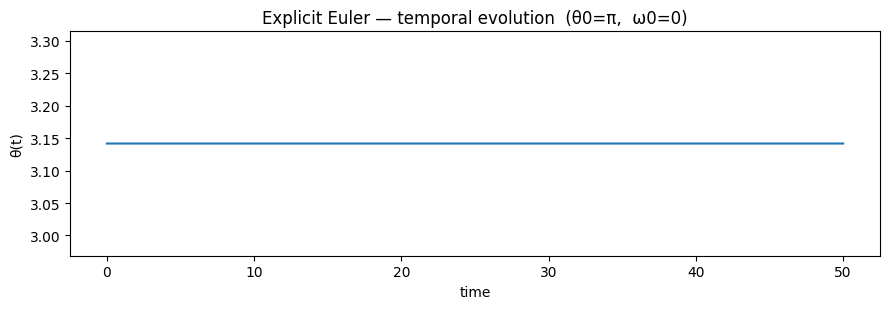

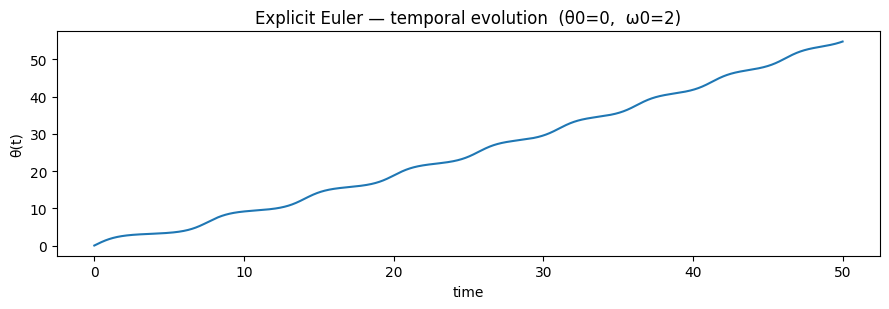

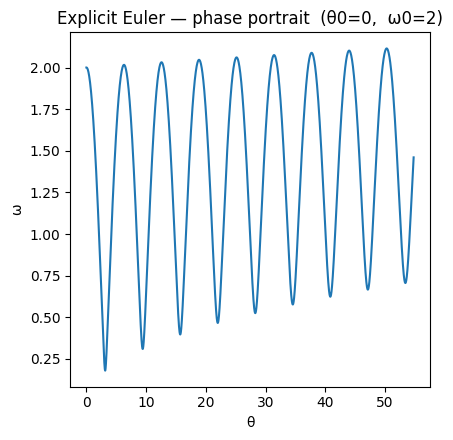

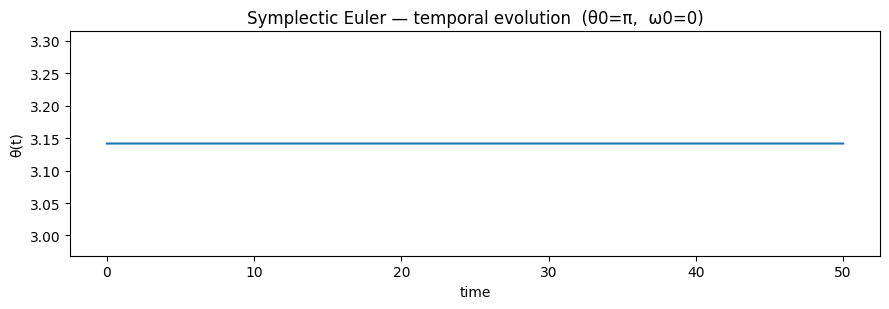

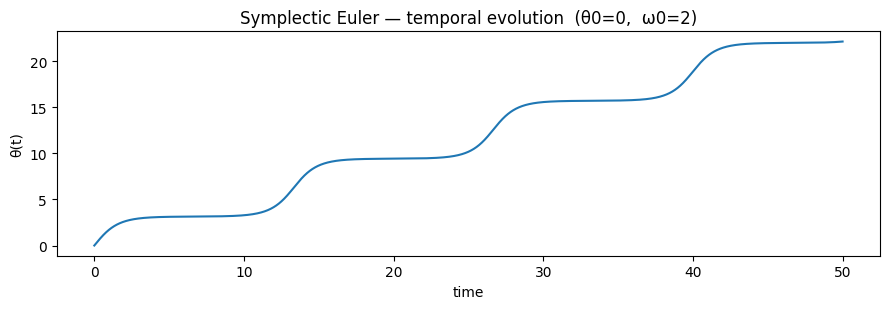

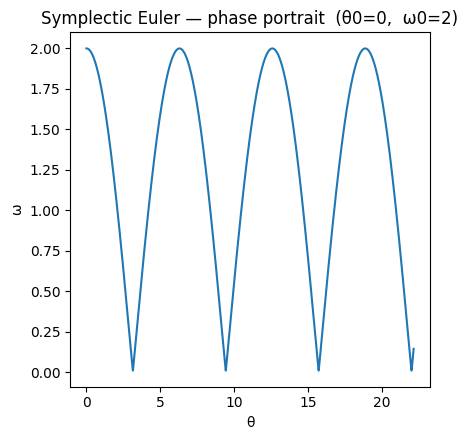

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ----- RHS of rigid pendulum -----
def f_pendulum(theta, omega, omega_0):
    dtheta = omega
    domega = - (omega_0**2) * math.sin(theta)
    return dtheta, domega

# ----- Simple (explicit) Euler -----
def euler_pendulum(theta0, omega0, omega_0, t0, tf, n_steps):
    dt = (tf - t0) / n_steps
    t = [t0]; th = [theta0]; om = [omega0]
    for _ in range(n_steps):
        dth, dom = f_pendulum(th[-1], om[-1], omega_0)
        th_new = th[-1] + dt * dth
        om_new = om[-1] + dt * dom
        t.append(t[-1] + dt); th.append(th_new); om.append(om_new)
    return t, th, om

# ----- Symplectic / semi-implicit Euler -----
# (update omega first, then theta using the new omega)
def euler_symplectic_pendulum(theta0, omega0, omega_0, t0, tf, n_steps):
    dt = (tf - t0) / n_steps
    t = [t0]; th = [theta0]; om = [omega0]
    for _ in range(n_steps):
        # use theta_k for acceleration
        _, dom = f_pendulum(th[-1], om[-1], omega_0)
        om_new = om[-1] + dt * dom
        th_new = th[-1] + dt * om_new
        t.append(t[-1] + dt); th.append(th_new); om.append(om_new)
    return t, th, om

# helper: mechanical energy to assess drift (optional)
def energy(theta, omega, omega_0):
    # take mL^2 = 1 so E = 1/2*omega^2 + omega_0^2*(1 - cos theta)
    return 0.5*np.array(omega)**2 + (omega_0**2)*(1 - np.cos(np.array(theta)))
omega_0 = 1.0
t0, tf = 0.0, 50.0
n_steps = 4000            # mesh density; decrease dt (increase n_steps) until results stabilize

ICs = [
    (math.pi, 0.0,  "θ0=π,  ω0=0"),   # Case 1: temporal θ(t)
    (0.0,     2.0,  "θ0=0,  ω0=2"),   # Case 2: temporal θ(t) + phase portrait
]

methods = [
    ("Explicit Euler",   euler_pendulum),
    ("Symplectic Euler", euler_symplectic_pendulum),
]

for mname, stepper in methods:
    for theta0, omega0_ic, label in ICs:
        t, th, om = stepper(theta0, omega0_ic, omega_0, t0, tf, n_steps)

        # θ(t)
        plt.figure(figsize=(9,3.2))
        plt.plot(t, th)
        plt.xlabel("time"); plt.ylabel("θ(t)")
        plt.title(f"{mname} — temporal evolution  ({label})")
        plt.tight_layout(); plt.show()

        # phase portrait only for the second IC
        if theta0 == 0.0 and omega0_ic == 2.0:
            plt.figure(figsize=(4.5,4.5))
            plt.plot(th, om)
            plt.xlabel("θ"); plt.ylabel("ω")
            plt.title(f"{mname} — phase portrait  ({label})")
            plt.tight_layout(); plt.show()

## Pseudocode for solving the rigid pendulum problem: Problem 2

1. **Import packages:** import `numpy` for constants, special functions, and linear algebra; import `matplotlib.pyplot` for plotting; import `scipy.integrate` for solving the differential equation (`solve_ivp`).
2. **Define the differential equation:** create a first-order system of equations. Define a function which takes in time `t`, and dependent varables `y`, and gives `dy/dt`. In our case, `y=[theta, ang_vel]`.
3. **Define the initial conditions, input paramters, and the time span:** `omega_0`, `y_0`, and `t_span`. The initial conditions are also a vector/array (`y_0 = [theta_0, ang_vel_0]`).
4. **Solve the differential equation:** call `solve_ivp`.
5. **Plot and explore the solution:** plot the temporal evolution, and a phase portrait, and compare with approximate solutions...

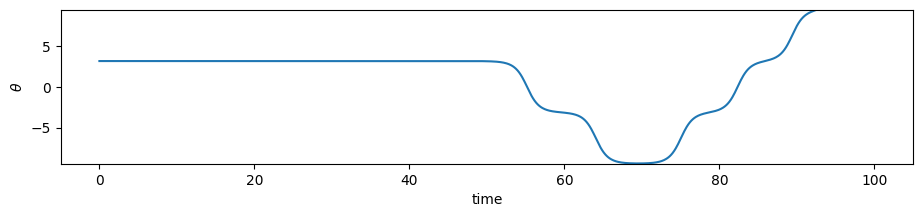

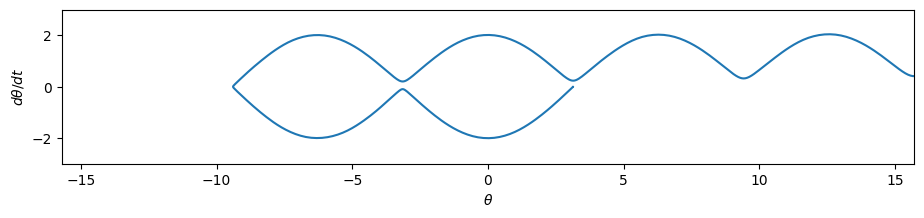

In [ ]:
# import packages
import numpy as np # imports the `numpy` package and gives it an alias/name `np`
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp # imports the `solve_ivp` function from the `integrate` submodule of the `scipy` module
# define our differential equation
def rigid_pendulum_ode(t, y, omega_0=1):
  """
  Returns the time derivative of y=[theta, ang_vel] (the angle and angular velocity).
  """
  theta, ang_vel = y # unpacks y=[theta, ang_vel]
  dtheta_dt = ang_vel # define first derivative
  d2theta_dt2 = - omega_0 ** 2 * np.sin(theta) # define second derivative
  dy_dt = [dtheta_dt, d2theta_dt2] # define derivative of state variable
  return dy_dt
# Define the initial conditions, input parameters, and the time span

theta_0 = np.pi # initial angle
ang_vel_0 = 0 # initial angular velocity
y_0 = [theta_0, ang_vel_0] # initial state

# input parameters
omega_0 = 1 # natural frequency

# time span
t_initial = 0 # initial time
t_final = 100 # final time
t_span = [t_initial, t_final] # time span

# solve differential equation
solution = solve_ivp(rigid_pendulum_ode, t_span, y_0, args=(omega_0,), dense_output=True)

# create list for plotting our solution
n_steps = 1000 # number of time steps
t_plot = np.linspace(t_initial, t_final, n_steps) # list of times for plotting
theta_plot = solution.sol(t_plot)[0] # evaluate the interpolant on a mesh for plotting
ang_vel_plot = solution.sol(t_plot)[1] # evaluate the interpolant on a mesh for plotting

# plot the temporal evolution
plt.figure(figsize=(11,2))
plt.plot(t_plot, theta_plot)
plt.xlabel("time")
plt.ylabel("$\\theta$")
plt.ylim(-3 * np.pi, 3 *np.pi)
plt.show()

# plot the phase portrait
plt.figure(figsize=(11,2))
plt.plot(theta_plot, ang_vel_plot)
plt.xlabel("$\\theta$")
plt.ylabel("$d\\theta/dt$")
plt.xlim(- 5 * np.pi, 5 * np.pi)
plt.ylim(-3, 3)
plt.show()

## Problem 3:

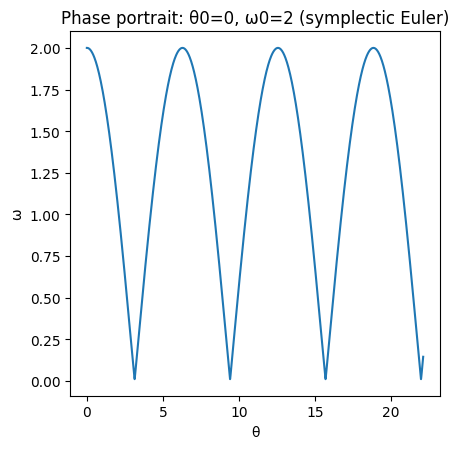

In [ ]:
import math, numpy as np, matplotlib.pyplot as plt  # imports

def euler_pendulum_symplectic(omega_0, theta_0, omega_init, t_0, t_f, n_steps):
    """
    Semi-implicit (symplectic) Euler for θ¨ = −ω0^2 sin θ.
    Updates ω first, then θ using the new ω (much better energy behavior).
    """
    dt = (t_f - t_0) / n_steps                # step size Δt
    theta = [theta_0]                         # store θ_k
    omega = [omega_init]                      # store ω_k (angular velocity)
    t     = [t_0]                             # store t_k
    for _ in range(n_steps):                  # main time loop
        # acceleration a(θ_k) = −ω0^2 sin θ_k
        domega = - (omega_0**2) * math.sin(theta[-1])  # compute ω derivative
        omega_new = omega[-1] + dt * domega            # symplectic: update ω first
        theta_new = theta[-1] + dt * omega_new         # then update θ with ω_{k+1}
        t_new     = t[-1] + dt                          # advance time

        # append new values
        theta.append(theta_new)                         # θ_{k+1}
        omega.append(omega_new)                         # ω_{k+1}
        t.append(t_new)                                 # t_{k+1}
    return t, theta, omega                              # return time series

# --- run with the required IC for overlay later ---
omega0_nat = 1.0                                       # natural frequency ω0
theta0, omega0_ic = 0.0, 2.0                           # θ0=0, ω0=2
t0, tf, N = 0.0, 50.0, 4000                            # time window and mesh density
t_num, th_num, om_num = euler_pendulum_symplectic(omega0_nat, theta0, omega0_ic, t0, tf, N)

# quick phase portrait of the numerical solution (will be overlaid on contours next)
plt.figure(figsize=(4.6,4.6))
plt.plot(th_num, om_num, lw=1.5)
plt.xlabel('θ'); plt.ylabel('ω'); plt.title('Phase portrait: θ0=0, ω0=2 (symplectic Euler)')
plt.tight_layout(); plt.show()


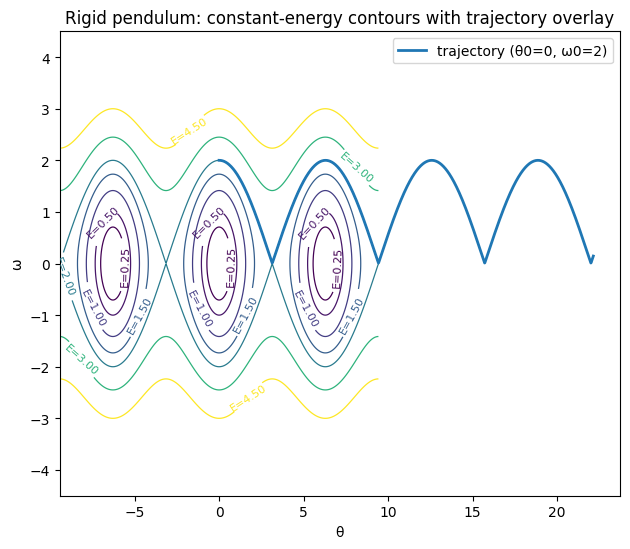

In [ ]:
# --- build energy grid and contours ---
th_grid = np.linspace(-3*np.pi, 3*np.pi, 600)                     # θ range
om_grid = np.linspace(-4.5, 4.5, 500)                             # ω range
TH, OM = np.meshgrid(th_grid, om_grid)                            # mesh
E = 0.5*OM**2 + (omega0_nat**2)*(1 - np.cos(TH))                  # energy on mesh

# choose energy levels (include the IC energy level)
E_ic = 0.5*(omega0_ic**2) + (omega0_nat**2)*(1 - math.cos(theta0))  # energy of IC
levels = np.r_[0.25, 0.5, 1.0, 1.5, 2.0, 3.0, 4.5, E_ic]           # add IC level
levels = np.unique(np.round(levels, 5))                            # tidy/unique

plt.figure(figsize=(6.4,5.6))
CS = plt.contour(TH, OM, E, levels=levels, linewidths=0.9)
plt.clabel(CS, inline=True, fontsize=8, fmt="E=%.2f")              # label contours

# overlay your numerical trajectory
plt.plot(th_num, om_num, lw=2.0, label=r'trajectory (θ0=0, ω0=2)')
plt.xlabel('θ'); plt.ylabel('ω')
plt.title('Rigid pendulum: constant-energy contours with trajectory overlay')
plt.legend(loc='upper right')
plt.tight_layout(); plt.show()


The contours are level sets of E(theta,omega) and represent constsant-energy orbits.
The symplectic Euler trajectory stays close to a single energy contour (bounded, nearly closed curve), showing much better energy conservation than simple Euler, which would visibly spiral due to numerical energy drift.
As you refine the mesh (decrease dt), the trajectory aligns more closely with the corresponding contour; with coarse dt, you'll see small, systematic deviations (numerical dispersion).